In [1]:
!pip install nltk scikit-learn tensorflow --quiet

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

nltk.download('stopwords')
from nltk.corpus import stopwords

2026-04-13 06:07:56.893997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776060477.149274      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776060477.221394      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776060477.807764      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776060477.807819      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776060477.807822      16 computation_placer.cc:177] computation placer alr

Load Data

In [3]:
!pip install pandas numpy nltk scikit-learn imbalanced-learn gdown tensorflow emoji

In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/peesalanaveen/datacet/Mental-health-related-subreddits.csv")

display(df.head())
print(df.shape)

/tmp/ipykernel_16/3252459592.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/peesalanaveen/datacet/Mental-health-related-subreddits.csv")


,Title,Text,Subreddit,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78
0,exposure does not work!,I have struggled with social anxiety from chil...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Panic attack? derealization? can't go to docto...,"Back in March (I know, a while ago D:), I woke...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,How long can a panic attack last?!,I've been withdrawing from medicines lately (e...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Stepping stones,"First time poster, long time lurker. \n\nI've ...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Coping with anxiety over climate change, on th...","Hi all,\n\nI made a throwaway account as my ma...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(488738, 79)


In [5]:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

In [6]:
print(df.shape)
print(df.columns)
df.info()

(488738, 3)
Index(['Title', 'Text', 'Subreddit'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488738 entries, 0 to 488737
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Title      488608 non-null  object
 1   Text       488573 non-null  object
 2   Subreddit  488535 non-null  object
dtypes: object(3)
memory usage: 11.2+ MB


In [7]:
df = df.dropna()

print(df.isnull().sum())

Title        0
Text         0
Subreddit    0
dtype: int64


In [8]:
valid_labels = [
    "depression",
    "mentalhealth",
    "Anxiety",
    "bipolar",
    "BPD",
    "schizophrenia",
    "autism"
]

# normalize text (very important)
df["Subreddit"] = df["Subreddit"].astype(str).str.strip()

# keep only valid labels
df = df[df["Subreddit"].isin(valid_labels)]

df = df[df["Subreddit"] != "mentalhealth"]

df["Subreddit"].value_counts()

Subreddit
depression       258490
Anxiety           86242
bipolar           41490
BPD               38210
schizophrenia     17505
autism             7142
Name: count, dtype: int64

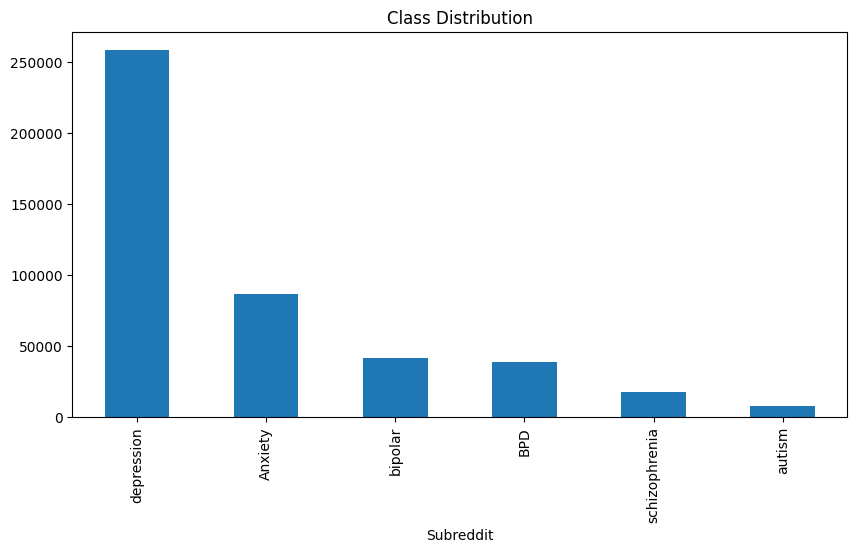

In [9]:
import matplotlib.pyplot as plt

df["Subreddit"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Class Distribution")
plt.show()

In [10]:
df["text_length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["text_length"].describe()

count    449079.000000
mean        184.987488
std         224.415564
min           0.000000
25%          60.000000
50%         121.000000
75%         229.000000
max        6597.000000
Name: text_length, dtype: float64

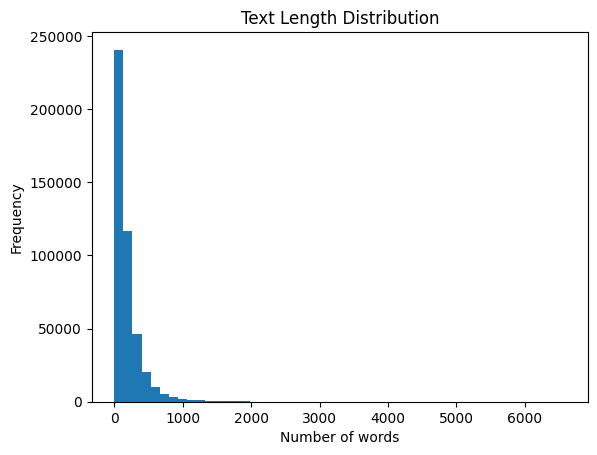

In [11]:
import matplotlib.pyplot as plt

plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [12]:
df = df[df["text_length"] > 0]
print(df.shape)

(449000, 4)


In [13]:
df["combined_text"] = df["Title"] + " " + df["Text"]

In [14]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["combined_text"].apply(clean_text)

In [15]:
MAX_WORDS = 300

df["clean_text"] = df["clean_text"].apply(
    lambda x: " ".join(x.split()[:MAX_WORDS])
)

<h3>Tokenization + Padding</h3>

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_vocab = 20000
max_len = 150

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

X = tokenizer.texts_to_sequences(df["clean_text"])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

<h3>Label Encoding</h3>

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df["Subreddit"])

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [19]:
from imblearn.over_sampling import SMOTE

# reshape for SMOTE (required)
nsamples, nx = X_train.shape
X_train_2d = X_train.reshape((nsamples, nx))

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_2d, y_train)

# reshape back
X_train_res = X_train_res.reshape((-1, max_len))

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_res))

Before SMOTE: [ 68984  30557   5710  33186 206762  14001]
After SMOTE : [206762 206762 206762 206762 206762 206762]


In [20]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class CapsuleLayer(Layer):
    def __init__(self, num_capsule, dim_capsule, routings=3, **kwargs):
        super(CapsuleLayer, self).__init__(**kwargs)
        self.num_capsule = num_capsule
        self.dim_capsule = dim_capsule
        self.routings = routings

    def build(self, input_shape):
        self.input_dim = input_shape[-1]

        self.W = self.add_weight(
            shape=(1, self.input_dim, self.num_capsule * self.dim_capsule),
            initializer='glorot_uniform',
            trainable=True
        )

    def call(self, inputs):
        batch_size = K.shape(inputs)[0]

        u_hat = K.dot(inputs, self.W[0])

        u_hat = K.reshape(
            u_hat,
            (batch_size, -1, self.num_capsule, self.dim_capsule)
        )

        # 🔥 STATIC ROUTING
        s_j = K.sum(u_hat, axis=1)

        # 🔥 SQUASH FUNCTION
        s_norm = K.sqrt(K.sum(K.square(s_j), axis=-1, keepdims=True) + K.epsilon())
        v_j = (s_norm**2 / (1 + s_norm**2)) * (s_j / (s_norm + K.epsilon()))

        return v_j

In [21]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv1D, MaxPooling1D

input_layer = Input(shape=(max_len,))

x = Embedding(max_vocab, 64)(input_layer)

# 🔥 CNN
x = Conv1D(128, 5, activation='relu', padding='same')(x)
x = MaxPooling1D(pool_size=2)(x)

# BiLSTM
x = Bidirectional(LSTM(32, return_sequences=True))(x)

# Capsule (static now)
x = CapsuleLayer(num_capsule=10, dim_capsule=16)(x)

x = Flatten()(x)

x = Dense(32, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(len(le.classes_), activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

2026-04-13 06:13:04.584737: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 150, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 75, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsule_layer (CapsuleLayer)    │ (None, 10, 16)         │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377,894 (5.26 MB)

 Trainable params: 1,377,894 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train_res, y_train_res,
    epochs=2,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/2
8723/8723 ━━━━━━━━━━━━━━━━━━━━ 1401s 160ms/step - accuracy: 0.4044 - loss: 1.4181 - val_accuracy: 0.0021 - val_loss: 2.4815
Epoch 2/2
8723/8723 ━━━━━━━━━━━━━━━━━━━━ 1363s 156ms/step - accuracy: 0.5083 - loss: 1.1921 - val_accuracy: 0.0032 - val_loss: 2.2589


In [23]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 48s 17ms/step


In [24]:
from sklearn.metrics import f1_score, accuracy_score, precision_score
import tensorflow as tf
import tensorflow.keras.backend as K

# Define binary Focal Loss function for one-vs-rest calculation
def binary_focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    """
    Binary focal loss, where y_true is 0 or 1.
    y_pred is the probability of the positive class.
    """
    epsilon = K.epsilon()
    y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

    loss_pos = -alpha * K.pow(1. - y_pred, gamma) * K.log(y_pred)
    loss_neg = -(1 - alpha) * K.pow(y_pred, gamma) * K.log(1. - y_pred)

    focal_loss_val = y_true * loss_pos + (1 - y_true) * loss_neg
    return K.mean(focal_loss_val)

results = []

for i, label in enumerate(le.classes_):

    y_true_bin = (y_test == i).astype(int)
    y_pred_bin = (y_pred == i).astype(int)
    y_pred_proba_class = y_pred_proba[:, i] # Get probability for the current class

    class_f1 = f1_score(y_true_bin, y_pred_bin)
    non_class_f1 = f1_score(1 - y_true_bin, 1 - y_pred_bin)
    acc = accuracy_score(y_true_bin, y_pred_bin) * 100
    precision = precision_score(y_true_bin, y_pred_bin)

    # Calculate Focal Loss for the current class (one-vs-rest)
    tf_y_true_bin = tf.convert_to_tensor(y_true_bin, dtype=tf.float32)
    tf_y_pred_proba_class = tf.convert_to_tensor(y_pred_proba_class, dtype=tf.float32)
    class_focal_loss = binary_focal_loss(tf_y_true_bin, tf_y_pred_proba_class).numpy()

    # Calculate Focal Loss for the non-class (one-vs-rest negative)
    non_class_focal_loss = binary_focal_loss(1 - tf_y_true_bin, 1 - tf_y_pred_proba_class).numpy()

    results.append([
        i,
        label,
        round(non_class_f1, 6),
        round(class_f1, 6),
        round(precision, 6),
        round(acc, 1),
        round(class_focal_loss, 6), # Add Class Focal Loss
        round(non_class_focal_loss, 6) # Add Non-Class Focal Loss
    ])

result_df = pd.DataFrame(
    results,
    columns=["Class", "Label", "Non-Class F1", "Class F1", "Precision", "Accuracy", "Class Focal Loss", "Non-Class Focal Loss"]
)

print(result_df)

   Class          Label  Non-Class F1  Class F1  Precision  Accuracy  \
0      0        Anxiety      0.956916  0.816274   0.825370      93.0   
1      1            BPD      0.975586  0.689576   0.827529      95.5   
2      2         autism      0.994292  0.684029   0.619670      98.9   
3      3        bipolar      0.968970  0.689236   0.701586      94.4   
4      4     depression      0.835905  0.887674   0.861525      86.7   
5      5  schizophrenia      0.988143  0.672719   0.759986      97.7   

   Class Focal Loss  Non-Class Focal Loss  
0          0.039116              0.056242  
1          0.024022              0.060477  
2          0.004301              0.010447  
3          0.022787              0.046826  
4          0.078934              0.095762  
5          0.011932              0.027542  


In [25]:
overall_accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Overall model accuracy: {overall_accuracy:.2f}%")

Overall model accuracy: 83.05%


Confusion Matrix for Each Class:


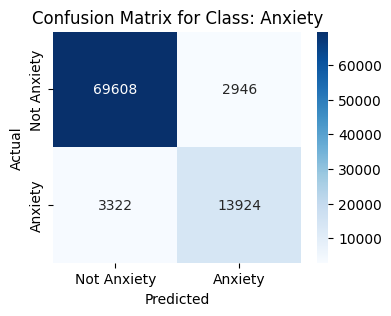

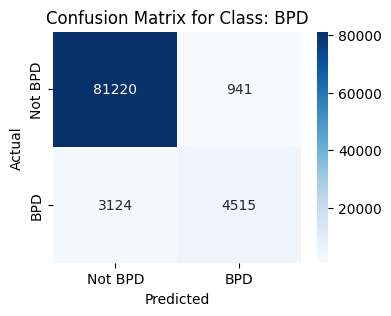

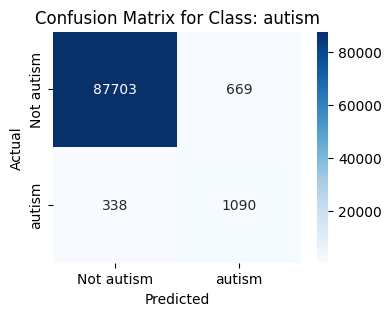

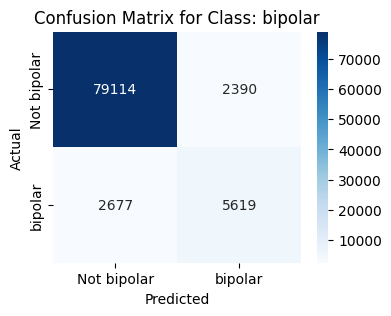

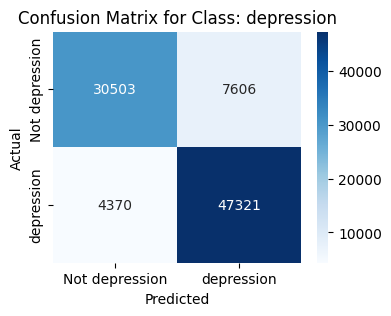

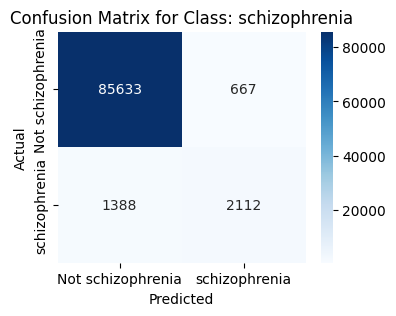


Overall Confusion Matrix:


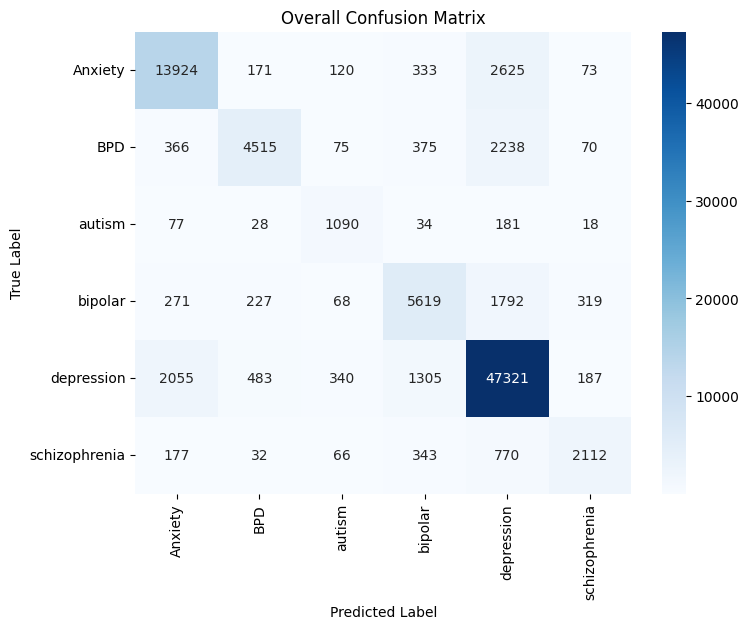

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for each class
print("Confusion Matrix for Each Class:")
for i, label in enumerate(le.classes_):
    y_true_bin = (y_test == i).astype(int)
    y_pred_bin = (y_pred == i).astype(int)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Not ' + label, label],
                yticklabels=['Not ' + label, label])
    plt.title(f"Confusion Matrix for Class: {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Overall Confusion Matrix
print("\nOverall Confusion Matrix:")
overall_cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    overall_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title("Overall Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 48s 17ms/step


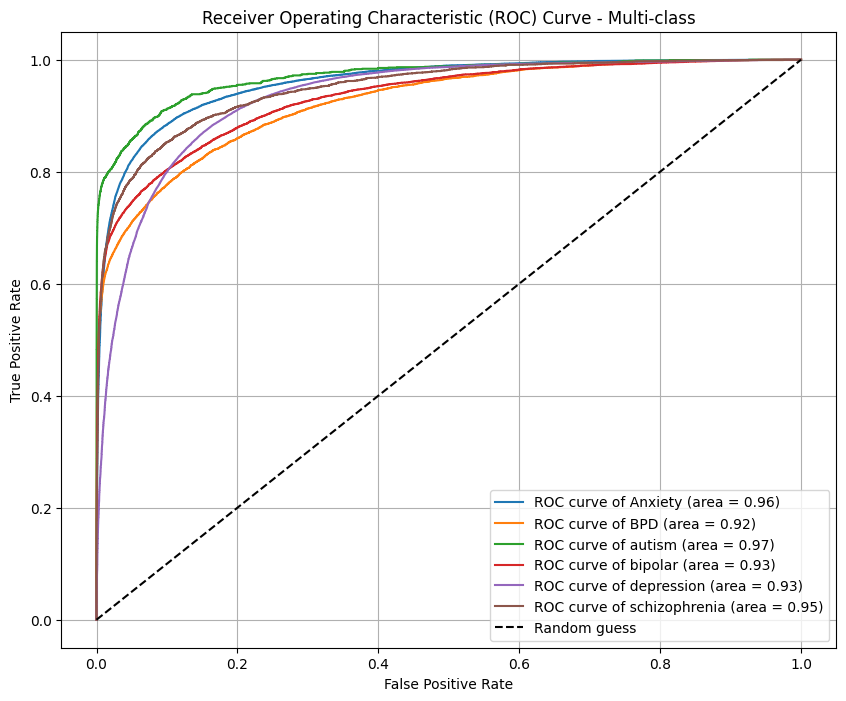

In [27]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the test set
y_pred_proba = model.predict(X_test)

# Binarize the true labels for one-vs-rest ROC
y_test_binarized = label_binarize(y_test, classes=np.arange(len(le.classes_)))

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of {class_label} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [28]:
# 🔥 ADD THIS FUNCTION BEFORE LIME
def predict_proba_func(texts):
    seq = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    return model.predict(padded)

# 🔥 STEP 1: Give manual input
input_text = "I feel tired and worthless..."

print("\n--- INPUT TEXT ---")
print(input_text)

# 🔥 STEP 2: Predict class probabilities
probs = predict_proba_func([input_text])[0]

# Get predicted class index
predicted_class_index = np.argmax(probs)

# 🔥 ADD BEFORE USING class_names
class_names = le.classes_

# Get predicted class name
predicted_class_name = class_names[predicted_class_index]

print("\n--- PREDICTION ---")
print(f"Predicted Class: {predicted_class_name}")
print(f"Class Probabilities: {probs}")

# 🔥 INSTALL + IMPORT LIME
!pip install lime --quiet

from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

# 🔥 STEP 3: LIME Explanation
explanation = explainer.explain_instance(
    input_text,
    predict_proba_func,
    num_features=10,
    labels=[predicted_class_index]  # explain predicted class
)

print("\n--- LIME EXPLANATION ---")
print(f"Top features for predicting '{predicted_class_name}':")

for feature, weight in explanation.as_list(label=predicted_class_index):
    print(f"  - {feature}: {weight:.4f}")

# 🔥 OPTIONAL: Save visualization
# explanation.save_to_file("lime_explanation.html")


--- INPUT TEXT ---
I feel tired and worthless...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

--- PREDICTION ---
Predicted Class: depression
Class Probabilities: [0.01632424 0.03886088 0.00274367 0.08748836 0.81828463 0.03629813]
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

--- LIME EXPLANATION ---
Top features for predicting 'depression':
  - worthless: 0.3303
  - tired: 0.2099
  - and: -0.0997
  - feel: 0.0766
  - I: -0.0695


In [29]:
# 🔥 VISUALIZATION (like paper)
from IPython.display import display, HTML

display(HTML(explanation.as_html()))

In [30]:
import pickle

# Save the Keras model
model.save('CONV_BILSTM_CAPS_Static_Model.keras')
print("Keras model saved as 'CONV_BILSTM_CAPS_static_Model.keras'")

# Save the Tokenizer
with open('CONV_BILSTM_CAPS_Static_tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle)
print("Tokenizer saved as 'CONV_BILSTM_CAPS_Static_tokenizer.pkl'")

# Save the LabelEncoder
with open('CONV_BILSTM_CAPS_Static_encoder.pkl', 'wb') as handle:
    pickle.dump(le, handle)
print("LabelEncoder saved as 'CONV_BILSTM_CAPS_Static_encoder.pkl'")

Keras model saved as 'CONV_BILSTM_CAPS_static_Model.keras'
Tokenizer saved as 'CONV_BILSTM_CAPS_Static_tokenizer.pkl'
LabelEncoder saved as 'CONV_BILSTM_CAPS_Static_encoder.pkl'


In [31]:
import tensorflow as tf
from tensorflow.keras.models import clone_model
import pandas as pd
from sklearn.metrics import f1_score
import numpy as np

# -------------------------------
# ONE-HOT LABELS (FIX)
# -------------------------------
y_train_res_cat = tf.keras.utils.to_categorical(y_train_res, num_classes=len(le.classes_))

# -------------------------------
# FOCAL LOSS
# -------------------------------
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)

        return tf.reduce_sum(weight * cross_entropy, axis=1)
    return loss


# -------------------------------
# FOCAL MODEL
# -------------------------------
model_focal = clone_model(model)
model_focal.set_weights(model.get_weights())

model_focal.compile(
    loss=focal_loss(),
    optimizer='adam',
    metrics=['accuracy']
)

model_focal.fit(
    X_train_res,
    y_train_res_cat,   # ✅ FIXED
    epochs=2,
    batch_size=128,
    verbose=0
)


# -------------------------------
# CONTRASTIVE (LABEL SMOOTHING FIXED)
# -------------------------------
model_contrast = clone_model(model)
model_contrast.set_weights(model.get_weights())

model_contrast.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # ✅ FIXED
    optimizer='adam',
    metrics=['accuracy']
)

model_contrast.fit(
    X_train_res,
    y_train_res_cat,   # ✅ FIXED
    epochs=2,
    batch_size=128,
    verbose=0
)


# -------------------------------
# F1 FUNCTION
# -------------------------------
def get_f1(model_used):
    y_pred = np.argmax(model_used.predict(X_test, verbose=0), axis=1)

    row = []
    for i in range(len(le.classes_)):
        y_true_bin = (y_test == i).astype(int)
        y_pred_bin = (y_pred == i).astype(int)

        non_f1 = f1_score(1 - y_true_bin, 1 - y_pred_bin) * 100
        cls_f1 = f1_score(y_true_bin, y_pred_bin) * 100

        row.extend([round(non_f1,2), round(cls_f1,2)])

    return row


baseline_row = get_f1(model)
focal_row = get_f1(model_focal)
contrast_row = get_f1(model_contrast)


# -------------------------------
# TABLE FORMAT
# -------------------------------
short = ["Dep","Anx","Bip","BPD","Schiz","Aut"]

cols = []
for s in short[:len(le.classes_)]:
    cols.extend([f"Non-{s}", s])


df_f1 = pd.DataFrame(
    [baseline_row, focal_row, contrast_row],
    index=[
        "Baseline (Conv_BiLSTM_Caps Static)",
        "Focal Loss",
        "Contrastive Loss"
    ],
    columns=cols
)

print("\n===== F1 SCORE TABLE =====\n")
print(df_f1)


===== F1 SCORE TABLE =====

                                    Non-Dep    Dep  Non-Anx    Anx  Non-Bip  \
Baseline (Conv_BiLSTM_Caps Static)    95.69  81.63    97.56  68.96    99.43   
Focal Loss                            95.72  81.07    97.60  69.04    99.46   
Contrastive Loss                      95.62  80.81    97.44  69.61    99.59   

                                      Bip  Non-BPD    BPD  Non-Schiz  Schiz  \
Baseline (Conv_BiLSTM_Caps Static)  68.40    96.90  68.92      83.59  88.77   
Focal Loss                          70.29    97.56  72.16      82.48  88.56   
Contrastive Loss                    75.18    97.59  73.16      83.76  88.89   

                                    Non-Aut    Aut  
Baseline (Conv_BiLSTM_Caps Static)    98.81  67.27  
Focal Loss                            98.22  57.61  
Contrastive Loss                      98.07  58.37  


In [32]:
from tensorflow.keras.layers import Multiply, Dense

def build_model(gate=None):

    inp = Input(shape=(max_len,))
    x = Embedding(max_vocab, 64)(inp)

    x = Conv1D(128, 5, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x)

    x = Bidirectional(LSTM(32, return_sequences=True))(x)

    # 🔥 GATING
    if gate == "sigmoid":
        g = Dense(x.shape[-1], activation='sigmoid')(x)
        x = Multiply()([x, g])

    elif gate == "elu":
        g = Dense(x.shape[-1], activation='elu')(x)
        x = Multiply()([x, g])

    x = CapsuleLayer(num_capsule=10, dim_capsule=16)(x)

    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.5)(x)

    out = Dense(len(le.classes_), activation='softmax')(x)

    m = Model(inp, out)
    m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return m


# TRAIN
model_sig = build_model("sigmoid")
model_sig.fit(X_train_res, y_train_res, epochs=2, batch_size=128, verbose=0)

model_elu = build_model("elu")
model_elu.fit(X_train_res, y_train_res, epochs=2, batch_size=128, verbose=0)


# -------------------------------
# ACCURACY PER CLASS
# -------------------------------
from sklearn.metrics import accuracy_score

def per_class_acc(m):
    yp = np.argmax(m.predict(X_test, verbose=0), axis=1)
    accs = []

    for i in range(len(le.classes_)):
        yt = (y_test == i).astype(int)
        yp_bin = (yp == i).astype(int)

        accs.append(round(accuracy_score(yt, yp_bin)*100,2))

    return accs


df_ablation = pd.DataFrame(
    [
        per_class_acc(model),
        per_class_acc(model_sig),
        per_class_acc(model_elu)
    ],
    index=[
        "Conv-BiLSTM-Capsule Static",
        "Static + Sigmoid",
        "Static + ELU"
    ],
    columns=le.classes_
)

print("\n===== ABLATION TABLE =====\n")
print(df_ablation)


===== ABLATION TABLE =====

                            Anxiety    BPD  autism  bipolar  depression  \
Conv-BiLSTM-Capsule Static    93.02  95.47   98.88    94.36       86.66   
Static + Sigmoid              92.99  95.46   99.27    95.51       86.60   
Static + ELU                  92.32  95.01   99.12    95.02       85.96   

                            schizophrenia  
Conv-BiLSTM-Capsule Static          97.71  
Static + Sigmoid                    96.50  
Static + ELU                        95.53  


In [33]:
import time
import pandas as pd

def complexity(m, name):
    p = round(m.count_params()/1e6,2)

    t1 = time.time()
    _ = m.predict(X_test[:100], verbose=0)
    t2 = time.time()

    t = int((t2-t1)*50)

    return [name, p, f"{t} s"]


df_complex = pd.DataFrame(
    [
        complexity(model, "Conv-BiLSTM-Capsule (Static)"),
        complexity(model_sig, "Static + Sigmoid"),
        complexity(model_elu, "Static + ELU")
    ],
    columns=[
        "Model variant",
        "Parameters (Millions)",
        "Training time (per epoch)"
    ]
)

print("\n===== MODEL COMPLEXITY =====\n")
print(df_complex)


===== MODEL COMPLEXITY =====

                  Model variant  Parameters (Millions)  \
0  Conv-BiLSTM-Capsule (Static)                   1.38   
1              Static + Sigmoid                   1.38   
2                  Static + ELU                   1.38   

  Training time (per epoch)  
0                       7 s  
1                       7 s  
2                       7 s  
